# Full Pipeline 01: HMM Regime Build + Full-Sample Inference

This notebook is the HMM entrypoint for the merged pipeline.

- Source of truth for regime selection: `scripts/train_hmm_regimes.py`
- HMM inputs: `data/processed/model_state_weekly_price_macro.csv`
- HMM feature preset: `regime_core`
- HMM selection mode: `pipeline`
- News inputs: `data/raw/news_sentiment/all_assets_news_weekly_finbert.csv`
- Outputs written to: `output/full_pipeline/`


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

REPO_ROOT = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "full_pipeline").exists() and (candidate / "scripts").exists():
        REPO_ROOT = candidate
        break
if REPO_ROOT is None:
    raise RuntimeError("Could not locate the repo root.")

PIPELINE_ROOT = REPO_ROOT / "full_pipeline"
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
if str(PIPELINE_ROOT) not in sys.path:
    sys.path.insert(0, str(PIPELINE_ROOT))

from _pipeline_utils import build_full_pipeline_artifacts, OUTPUT_DIR

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("deep")
pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 180)


## Run the HMM + News Merge Pipeline

This executes three steps:

1. Aggregate weekly FinBERT sentiment for SPY, TLT, GLD, VIX, and TNX.
2. Run the objective-aware HMM selection workflow and refit the chosen model on the development window.
3. Infer full-sample causal regime probabilities and assemble the merged state table for RL/evaluation.


In [2]:
artifacts = build_full_pipeline_artifacts()

base_state = artifacts["base_state"]
news_features = artifacts["news_features"]
hmm_bundle = artifacts["hmm_bundle"]
hmm_full = artifacts["hmm_full"]
merged_state = artifacts["merged_state"]
artifact_paths = artifacts["artifact_paths"]

print("Artifacts written to:")
for name, path in artifact_paths.items():
    print(f"  {name}: {path.relative_to(REPO_ROOT)}")



Grid search  K ∈ [2, 3, 4]  n_pca ∈ [8, 10, 12, 14]  cov ∈ {diag,full}  seeds ∈ [7, 21, 42, 84, 168] (best kept)  (24 candidates)

  K  n_pca     cov   seed  val_ll/step  val_min_pct  val_min_dur   hard  interp    tier      status
───────────────────────────────────────────────────────────────────────────────────────────────────
  2      8    diag      7     -25.6562        43.3%         22.5      Y       8/8    High          OK


Model is not converging.  Current: -2943.848886052938 is not greater than -2943.8488723181813. Delta is -1.373475652144407e-05


  2      8    full     21     -46.1169        32.7%         34.0      Y       8/8    High          OK
  2     10    diag     42     -50.3963         0.0%        104.0      —       0/8     Low    collapse
  2     10    full      7    -128.2686        15.4%          5.3      Y       7/8    High          OK


Model is not converging.  Current: -2624.638751454131 is not greater than -2624.638742075136. Delta is -9.378994946018793e-06


Model is not converging.  Current: -2609.417947005656 is not greater than -2609.4179461935346. Delta is -8.121214705170132e-07


...

Model is not converging.  Current: -2718.271061247903 is not greater than -2718.271027425156. Delta is -3.382274735486135e-05


Model is not converging.  Current: -1644.4425041885954 is not greater than -1644.4419536725195. Delta is -0.0005505160759184946


  4     12    full     42    -144.5344         0.0%          5.6      —       0/8     Low    collapse
  4     14    diag      7    -118.2612         0.0%         14.0      —       0/8     Low    collapse


Model is not converging.  Current: -1831.692028958363 is not greater than -1831.6920181783933. Delta is -1.077996967069339e-05


  4     14    full     21    -391.7438         1.9%          1.0      —       0/8     Low    collapse
Artifacts written to:
  news_features: output/full_pipeline/news_features_weekly_finbert_5assets.csv
  hmm_full: output/full_pipeline/hmm_regimes_full_sample.csv
  merged_state: output/full_pipeline/model_state_weekly_hmm_news.csv
  validation_actions: output/full_pipeline/rl_validation_actions.csv
  locked_test_actions: output/full_pipeline/rl_locked_test_actions.csv


In [3]:
coverage_df = pd.DataFrame([artifacts["news_coverage"]])
hmm_validation_df = pd.DataFrame([artifacts["hmm_validation"]])

print("Weekly FinBERT coverage")
display(coverage_df)

print("HMM posterior validation")
display(hmm_validation_df)


Weekly FinBERT coverage


,base_rows,news_rows,covered_rows,first_week,last_week
0,625,638,625,2014-03-28,2026-03-13


HMM posterior validation


,n_rows,n_regimes,max_probability_sum_deviation
0,625,2,8.959500e-13


In [4]:
results_df = pd.DataFrame(
    [{k: v for k, v in result.items() if not k.startswith("_")} for result in hmm_bundle.results]
).sort_values(
    ["passes_hard_filters", "interpretability_score", "val_ll_per_step"],
    ascending=[False, False, False],
).reset_index(drop=True)

selected_rows = []
for label, result in [
    ("best_statistical", hmm_bundle.best_statistical),
    ("best_interpretable", hmm_bundle.best_interpretable),
    ("best_k3", hmm_bundle.best_k3),
    ("chosen_for_pipeline", hmm_bundle.chosen),
]:
    if result is None:
        continue
    selected_rows.append(
        {
            "role": label,
            "K": result["K"],
            "n_pca": result["n_pca"],
            "cov_type": result["cov_type"],
            "selected_seed": result["selected_seed"],
            "val_ll_per_step": result["val_ll_per_step"],
            "interpretability_score": result["interpretability_score"],
            "interpretability_tier": result["interpretability_tier"],
        }
    )

print("Selected candidates")
display(pd.DataFrame(selected_rows))

print("Top grid-search candidates")
display(
    results_df.loc[
        :,
        [
            "K",
            "n_pca",
            "cov_type",
            "selected_seed",
            "val_ll_per_step",
            "passes_hard_filters",
            "interpretability_score",
            "interpretability_tier",
        ],
    ].head(12)
)

print("Selection reason:")
print(hmm_bundle.selection_reason)
print(f"Feature preset: {hmm_bundle.feature_preset}")
print(f"Selection mode: {hmm_bundle.selection_mode}")
print(f"Selection role: {hmm_bundle.selection_role}")


Selected candidates


,role,K,n_pca,cov_type,selected_seed,val_ll_per_step,interpretability_score,interpretability_tier
0,best_statistical,2,8,diag,7,-25.656235,8,High
1,best_interpretable,2,8,diag,7,-25.656235,8,High
2,best_k3,3,10,full,42,-126.710208,7,High
3,chosen_for_pipeline,2,8,diag,7,-25.656235,8,High


Top grid-search candidates


,K,n_pca,cov_type,selected_seed,val_ll_per_step,passes_hard_filters,interpretability_score,interpretability_tier
0,2,8,diag,7,-25.656235,True,8,High
1,2,8,full,21,-46.116894,True,8,High
2,2,14,full,21,-360.003858,True,8,High
3,3,10,full,42,-126.710208,True,7,High
4,2,10,full,7,-128.268620,True,7,High
5,2,12,full,42,-146.546053,True,7,High
6,3,8,diag,42,-19.465422,False,0,Low
7,4,8,diag,7,-20.294992,False,0,Low
8,3,8,full,42,-29.883778,False,0,Low
9,4,8,full,7,-40.294257,False,0,Low


Selection reason:
Best interpretable candidate also has the best validation log-likelihood among survivors — no interpretability/likelihood trade-off to resolve.
Feature preset: regime_core
Selection mode: pipeline
Selection role: project


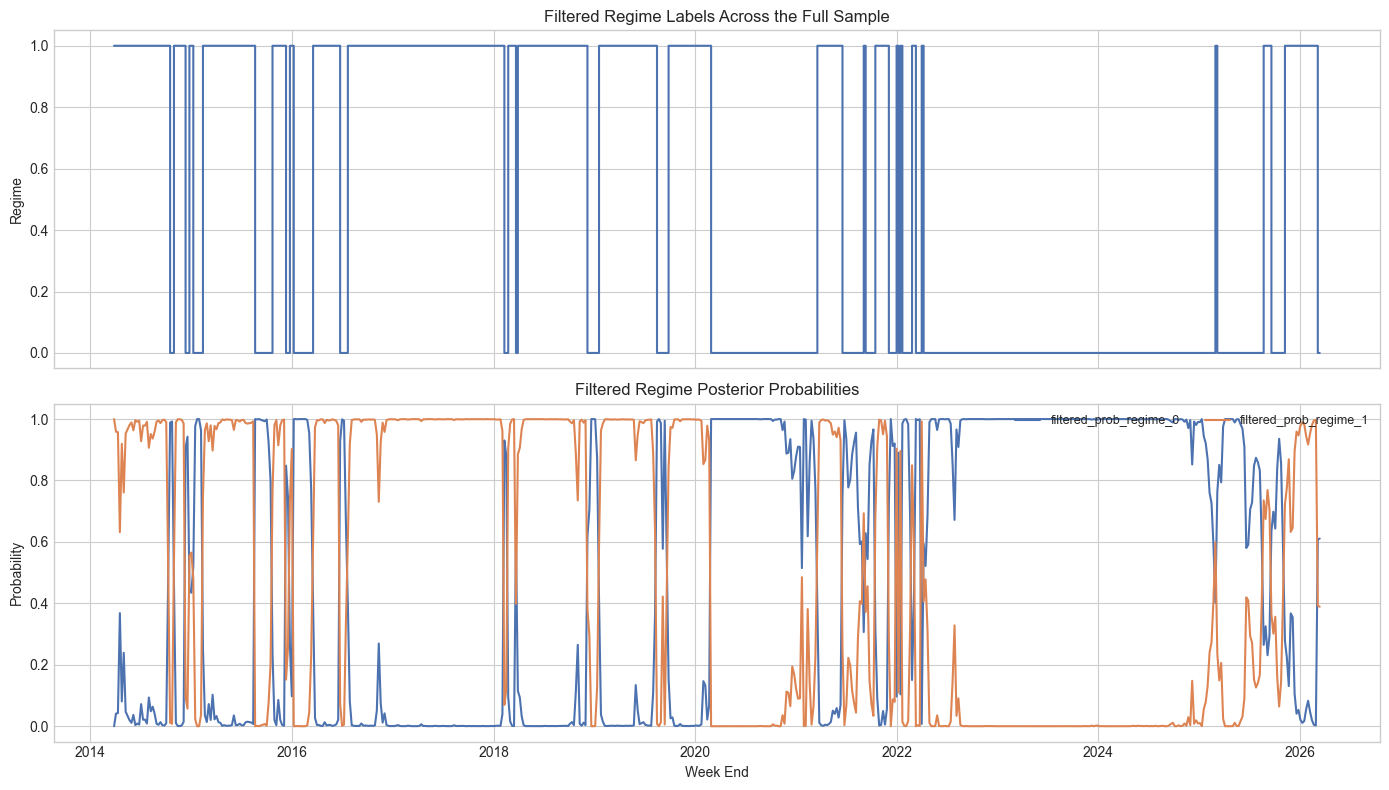

,n_weeks
regime_filtered,
0,317
1,308


In [5]:
filtered_cols = sorted(column for column in hmm_full.columns if column.startswith("filtered_prob_regime_"))
regime_counts = hmm_full["regime_filtered"].value_counts().sort_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(hmm_full["week_end"], hmm_full["regime_filtered"], drawstyle="steps-post", linewidth=1.5)
axes[0].set_title("Filtered Regime Labels Across the Full Sample")
axes[0].set_ylabel("Regime")

for column in filtered_cols:
    axes[1].plot(hmm_full["week_end"], hmm_full[column], label=column)
axes[1].set_title("Filtered Regime Posterior Probabilities")
axes[1].set_ylabel("Probability")
axes[1].set_xlabel("Week End")
axes[1].legend(loc="upper right", ncol=2, fontsize=9)

plt.tight_layout()
plt.show()

regime_counts.to_frame("n_weeks")


In [6]:
print("Merged state shape:", merged_state.shape)
print("Merged state columns:", len(merged_state.columns))
display(merged_state.head(3))

missing_summary = pd.Series(
    {
        "missing_regime_rows": int(merged_state["regime_filtered"].isna().sum()),
        "missing_news_rows": int(
            merged_state.filter(like="news_finbert_compound_").isna().any(axis=1).sum()
        ),
    }
)
display(missing_summary.to_frame("value"))


Merged state shape: (625, 84)
Merged state columns: 84


,week_end,spy_ret_1d,spy_ret_5d,spy_ret_20d,spy_vol_5d,spy_vol_20d,spy_drawdown_60d,spy_ma_gap_5_20,spy_intraday_range,spy_volume_z_20,tlt_ret_1d,tlt_ret_5d,tlt_ret_20d,tlt_vol_5d,tlt_vol_20d,tlt_drawdown_60d,tlt_ma_gap_5_20,tlt_intraday_range,tlt_volume_z_20,gld_ret_1d,gld_ret_5d,gld_ret_20d,gld_vol_5d,gld_vol_20d,gld_drawdown_60d,gld_ma_gap_5_20,gld_intraday_range,gld_volume_z_20,qqq_spy_log_ratio,qqq_spy_ratio_chg_5d,spy_tlt_corr_20d,spy_gld_corr_20d,vix_level,vix_change_5d,tnx_level,tnx_change_5d,week_last_trade_date,bamlh0a0hym2_level,bamlh0a0hym2_chg_5d,cfnai_level,cfnai_mean_3m,cpi_yoy,dff_level,dff_chg_5d,dgs10_level,dgs10_chg_5d,dgs3mo_level,dgs3mo_chg_5d,dtwexbgs_level,dtwexbgs_pct_chg_5d,icsa_log_level,icsa_chg_4w,nfci_level,nfci_chg_4w,permit_yoy,t10y3m_level,t10y3m_sign,t10y3m_chg_5d,t10yie_level,t10yie_chg_5d,umcsent_level,umcsent_chg_3m,unrate_level,unrate_chg_3m,vixcls_level,vixcls_chg_5d,wresbal_log_level,wresbal_pct_chg_4w,spy_weekly_close,tlt_weekly_close,gld_weekly_close,next_return_spy,next_return_tlt,next_return_gld,source,regime_filtered,regime_viterbi,filtered_prob_regime_0,filtered_prob_regime_1,news_finbert_compound_spy,news_finbert_compound_tlt,news_finbert_compound_gld,news_finbert_compound_vix,news_finbert_compound_tnx
0,2014-03-28,0.004918,-0.003820,0.000100,0.005418,0.006242,-0.010365,-0.003231,0.007655,-0.613129,-0.005652,0.010478,0.009767,0.006332,0.007535,-0.005636,0.012917,0.007955,-0.431690,-0.000241,-0.030908,-0.024270,0.007777,0.010379,-0.064162,-0.026546,0.008671,-0.297768,-0.644319,-0.018334,-0.715246,-0.248972,14.410000,-0.590000,2.712,-0.038,2014-03-28,3.73,-0.03,0.44,-0.136667,0.011205,0.08,0.00,2.73,-0.02,0.04,-0.02,94.3683,-0.005128,12.679196,-11000.0,-0.78049,-0.00672,0.060204,2.69,1.0,0.00,2.13,-0.01,81.6,6.5,6.7,-0.2,14.41,-0.59,14.776391,0.001294,151.332809,78.876373,124.559998,0.004905,-0.005769,0.008109,joined_market_macro_targets_hmm_finbert_news,1,1,1.191012e-15,1.000000,-0.814561,-0.072487,0.020211,0.118187,-0.072487
1,2014-04-04,-0.011893,0.004893,-0.005526,0.008060,0.006294,-0.013131,0.008322,0.019313,1.507661,0.006661,-0.005786,0.026551,0.006515,0.006523,-0.011373,0.001623,0.007745,0.770457,0.013227,0.008076,-0.027646,0.008522,0.009143,-0.056574,-0.026448,0.008760,-0.203297,-0.657054,-0.012736,-0.680866,-0.198760,13.960000,-0.450000,2.726,0.014,2014-04-04,3.68,-0.05,0.48,0.073333,0.016127,0.08,0.00,2.74,0.01,0.03,-0.01,94.2191,-0.001581,12.653958,-28000.0,-0.77771,0.00026,0.139957,2.71,1.0,0.02,2.13,0.00,80.0,-2.5,6.7,0.0,13.96,-0.45,14.775309,0.000241,152.075150,78.421341,125.570000,-0.026234,0.020929,0.010831,joined_market_macro_targets_hmm_finbert_news,1,1,4.107824e-02,0.958922,-0.695816,0.011783,-0.020225,0.829025,0.106177
2,2014-04-11,-0.009049,-0.026584,-0.012802,0.012709,0.008502,-0.039020,-0.009052,0.011625,1.308151,0.008070,0.020713,0.022730,0.005712,0.006483,0.000000,0.009900,0.005960,1.129848,-0.000630,0.010772,-0.047465,0.005621,0.008473,-0.046356,-0.000340,0.004569,-1.025681,-0.656986,0.000069,-0.706057,-0.110863,17.030001,3.070001,2.619,-0.107,2014-04-11,3.82,0.14,0.48,0.073333,0.016127,0.09,0.01,2.63,-0.11,0.04,0.01,93.6395,-0.006152,12.706848,11000.0,-0.77580,0.00515,0.139957,2.59,1.0,-0.12,2.13,0.00,80.0,-2.5,6.7,0.0,17.03,3.07,14.775538,-0.017789,148.085648,80.062637,126.930000,0.026886,-0.006141,-0.017175,joined_market_macro_targets_hmm_finbert_news,1,1,4.290745e-02,0.957093,-0.143139,-0.470965,-0.055684,-0.143139,-0.054710


,value
missing_regime_rows,0
missing_news_rows,0
